# 23CSE463 – Quantum Computing
## Worksheet 5: Design and Verification of the Quantum Fourier Transform (QFT) Using Qiskit

**Name:** Agneay B Nair  
**Reg. No:** CH.SC.U4CSE24102  
**Ex. No:** 5

**Aim:** To construct the Quantum Fourier Transform and its inverse for one, two and three qubits in Qiskit using Hadamard, controlled-phase and SWAP gates, and to verify the circuits against the QFT matrix.

### Setup

In [1]:
# Common setup for all programs in this worksheet
%matplotlib inline
import qiskit, numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit version:", qiskit.__version__)
sim = AerSimulator()
_seed = 2024                                      # seeds incremented per run -> reproducible counts
np.set_printoptions(precision=3, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 100

def show(fig):
    """display a matplotlib figure (circuit diagram / histogram) and close it"""
    display(fig); plt.close(fig)

def run(qc, shots=1024):
    global _seed
    _seed += 1
    return sim.run(transpile(qc, sim), shots=shots, seed_simulator=_seed).result().get_counts()

def amps(sv, tol=1e-9):
    """print the non-zero amplitudes of a statevector with Qiskit labels (qubit 0 rightmost)"""
    n = sv.num_qubits
    for i, a in enumerate(sv.data):
        if abs(a) > tol:
            print(f"  |{i:0{n}b}> : {a.real:+.3f}{a.imag:+.3f}j   P = {abs(a)**2:.3f}")


from qiskit.circuit.library import QFTGate

def qft(n, swaps=True):
    """n-qubit QFT: H + controlled-phase gates from the most significant qubit down, then SWAPs"""
    qc = QuantumCircuit(n, name=f"QFT{n}")
    for j in reversed(range(n)):
        qc.h(j)
        for k in reversed(range(j)):
            qc.cp(np.pi / 2 ** (j - k), k, j)
        if n > 1:
            qc.barrier()
    if swaps:
        for i in range(n // 2):
            qc.swap(i, n - 1 - i)
    return qc

def iqft(n):
    g = qft(n).inverse(); g.name = f"IQFT{n}"
    return g

def qft_matrix(n):
    N = 2 ** n
    w = np.exp(2j * np.pi / N)
    return np.array([[w ** (j * k) for j in range(N)] for k in range(N)]) / np.sqrt(N)


Qiskit version: 2.5.2


### Program 1
Show that the one-qubit QFT is the Hadamard gate by comparing the two operators.

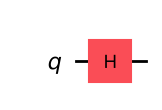

QFT_1 matrix:
 [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
H matrix:
 [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
Formula matrix (omega = -1):
 [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
QFT_1 == H : True    matches formula: True


In [2]:
# Program 1: one-qubit QFT = Hadamard
q1 = qft(1)
h = QuantumCircuit(1); h.h(0)
show(q1.draw("mpl"))
print("QFT_1 matrix:\n", np.round(Operator(q1).data, 3))
print("H matrix:\n", np.round(Operator(h).data, 3))
print("Formula matrix (omega = -1):\n", np.round(qft_matrix(1), 3))
print("QFT_1 == H :", Operator(q1).equiv(Operator(h)), "   matches formula:", np.allclose(Operator(q1).data, qft_matrix(1)))

**Inference:** For N = 2, ω = e^(iπ) = −1 and the QFT matrix is (1/√2)[[1,1],[1,−1]], which is exactly the Hadamard gate; the circuit consists of a single H and the operators are identical.

### Program 2
Construct the two-qubit QFT from two Hadamard gates, one controlled-phase gate and one SWAP gate. Display its matrix and compare it with the matrix in the theory.

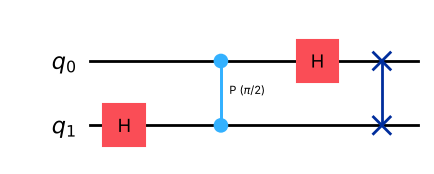

Circuit matrix (x2 for readability):
 [[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j]
 [ 1.+0.j  0.+1.j -1.+0.j -0.-1.j]
 [ 1.+0.j -1.+0.j  1.+0.j -1.+0.j]
 [ 1.+0.j -0.-1.j -1.+0.j  0.+1.j]]
Equal to the theory matrix QFT_4: True


In [3]:
# Program 2: two-qubit QFT = H(q1), CP(pi/2), H(q0), SWAP
qc = QuantumCircuit(2)
qc.h(1)
qc.cp(np.pi / 2, 0, 1)
qc.h(0)
qc.swap(0, 1)
show(qc.draw("mpl"))
U = Operator(qc).data
print("Circuit matrix (x2 for readability):\n", np.round(2 * U, 3))
theory = 0.5 * np.array([[1, 1, 1, 1], [1, 1j, -1, -1j], [1, -1, 1, -1], [1, -1j, -1, 1j]])
print("Equal to the theory matrix QFT_4:", np.allclose(U, theory))

**Inference:** Using two Hadamards, one controlled-phase π/2 and one SWAP, the circuit's matrix is ½[[1,1,1,1],[1,i,−1,−i],[1,−1,1,−1],[1,−i,−1,i]], identical to QFT₄ in the theory (np.allclose = True).

### Program 3
Construct the three-qubit QFT. Draw the circuit and display its 8 × 8 matrix rounded to three decimal places.

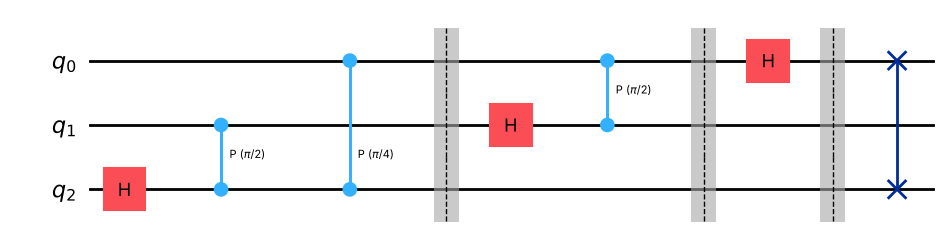

8x8 QFT matrix (rounded to 3 decimals):
[[ 0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j   ]
 [ 0.354+0.j     0.25 +0.25j   0.   +0.354j -0.25 +0.25j  -0.354+0.j    -0.25 -0.25j  -0.   -0.354j  0.25 -0.25j ]
 [ 0.354+0.j     0.   +0.354j -0.354+0.j    -0.   -0.354j  0.354+0.j     0.   +0.354j -0.354+0.j    -0.   -0.354j]
 [ 0.354+0.j    -0.25 +0.25j  -0.   -0.354j  0.25 +0.25j  -0.354+0.j     0.25 -0.25j   0.   +0.354j -0.25 -0.25j ]
 [ 0.354+0.j    -0.354+0.j     0.354+0.j    -0.354+0.j     0.354+0.j    -0.354+0.j     0.354+0.j    -0.354+0.j   ]
 [ 0.354+0.j    -0.25 -0.25j   0.   +0.354j  0.25 -0.25j  -0.354+0.j     0.25 +0.25j  -0.   -0.354j -0.25 +0.25j ]
 [ 0.354+0.j    -0.   -0.354j -0.354+0.j     0.   +0.354j  0.354+0.j    -0.   -0.354j -0.354+0.j     0.   +0.354j]
 [ 0.354+0.j     0.25 -0.25j  -0.   -0.354j -0.25 -0.25j  -0.354+0.j    -0.25 +0.25j   0.   +0.354j  0.25 +0.25j ]]


In [4]:
# Program 3: three-qubit QFT
q3 = qft(3)
show(q3.draw("mpl"))
U3 = Operator(q3).data
np.set_printoptions(precision=3, suppress=True, linewidth=160)
print("8x8 QFT matrix (rounded to 3 decimals):")
print(np.round(U3, 3))
np.set_printoptions(precision=3, suppress=True, linewidth=110)

**Inference:** The 3-qubit QFT uses 3 H, 3 controlled-phase gates (π/2, π/4, π/2) and 1 SWAP. Every entry of the 8×8 matrix has magnitude 1/√8 = 0.354 with phases that are multiples of 45° (e.g. 0.25+0.25i = e^(iπ/4)/√8), exactly ω^(jk)/√8 with ω = e^(iπ/4).

### Program 4
Verify the three-qubit QFT circuit against the matrix computed from the formula with NumPy (np.allclose), and against Qiskit\'s QFTGate.

In [5]:
# Program 4: verify the 3-qubit QFT against the formula and QFTGate
ref = QuantumCircuit(3); ref.append(QFTGate(3), range(3))
print("Circuit == formula matrix (np.allclose):", np.allclose(Operator(q3).data, qft_matrix(3)))
print("Circuit == Qiskit QFTGate (Operator.equiv):", Operator(q3).equiv(Operator(ref)))
print("Max |difference| from formula:", np.max(np.abs(Operator(q3).data - qft_matrix(3))))

Circuit == formula matrix (np.allclose): True
Circuit == Qiskit QFTGate (Operator.equiv): True
Max |difference| from formula: 1.885745754155791e-15


**Inference:** The hand-built circuit equals the formula e^(2πijk/N)/√N to machine precision and is equivalent to Qiskit's QFTGate, so the gate sequence and the qubit ordering (qubit 0 least significant) are correct.

### Program 5
Apply the three-qubit QFT to $|000\rangle$ and to $|101\rangle$. Display the amplitudes, their phases and the probabilities, and explain why all eight probabilities are equal.

In [6]:
# Program 5: QFT of |000> and |101>
for label in ["000", "101"]:
    sv = Statevector.from_label(label).evolve(q3)
    j = int(label, 2)
    print(f"QFT|{label}> (j = {j}):")
    print("   k   amplitude          |amp|   phase(deg)  phase/(2pi/8)   prob")
    for k, a in enumerate(sv.data):
        ph = np.degrees(np.angle(a)) % 360
        print(f"   {k}   {a.real:+.3f}{a.imag:+.3f}j    {abs(a):.3f}   {ph:7.1f}      {round(ph/45) % 8}           {abs(a)**2:.3f}")
    print()

QFT|000> (j = 0):
   k   amplitude          |amp|   phase(deg)  phase/(2pi/8)   prob
   0   +0.354+0.000j    0.354       0.0      0           0.125
   1   +0.354+0.000j    0.354       0.0      0           0.125
   2   +0.354+0.000j    0.354       0.0      0           0.125
   3   +0.354+0.000j    0.354       0.0      0           0.125
   4   +0.354+0.000j    0.354       0.0      0           0.125
   5   +0.354+0.000j    0.354       0.0      0           0.125
   6   +0.354+0.000j    0.354       0.0      0           0.125
   7   +0.354+0.000j    0.354       0.0      0           0.125

QFT|101> (j = 5):
   k   amplitude          |amp|   phase(deg)  phase/(2pi/8)   prob
   0   +0.354+0.000j    0.354       0.0      0           0.125
   1   -0.250-0.250j    0.354     225.0      5           0.125
   2   +0.000+0.354j    0.354      90.0      2           0.125
   3   +0.250-0.250j    0.354     315.0      7           0.125
   4   -0.354+0.000j    0.354     180.0      4           0.125
   5   +0.

**Inference:** QFT|000> is the uniform superposition with all phases 0. For |101> (j = 5) every amplitude still has magnitude 1/√8, with phase 2π·5k/8 (k·225° mod 360°, i.e. 5k mod 8 in units of 45°). All eight probabilities equal 1/8 = 0.125 because the QFT of a basis state only changes phases, never magnitudes — the information is entirely in the phases.

### Program 6
Construct the inverse QFT and verify that the QFT followed by the inverse QFT returns the input for all eight basis states.

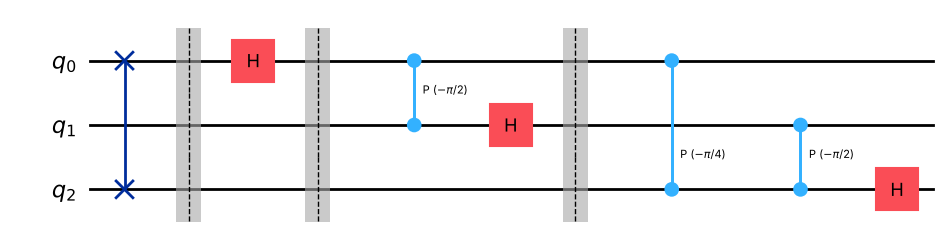

|000> -> QFT -> IQFT -> 000   OK


|001> -> QFT -> IQFT -> 001   OK
|010> -> QFT -> IQFT -> 010   OK
|011> -> QFT -> IQFT -> 011   OK
|100> -> QFT -> IQFT -> 100   OK
|101> -> QFT -> IQFT -> 101   OK
|110> -> QFT -> IQFT -> 110   OK
|111> -> QFT -> IQFT -> 111   OK
QFT . IQFT = identity: True   all states recovered: True


In [7]:
# Program 6: inverse QFT; QFT followed by inverse QFT returns every basis state
inv3 = iqft(3)
show(inv3.draw("mpl"))
ok = []
for i in range(8):
    lab = f"{i:03b}"
    out = Statevector.from_label(lab).evolve(q3).evolve(inv3)
    back = out.probabilities_dict(decimals=6)
    ok.append(list(back) == [lab] and np.isclose(abs(out.data[i]), 1))
    print(f"|{lab}> -> QFT -> IQFT -> {list(back)[0]}   {'OK' if ok[-1] else 'FAIL'}")
print("QFT . IQFT = identity:", Operator(q3.compose(inv3)).equiv(Operator(QuantumCircuit(3))), "  all states recovered:", all(ok))

**Inference:** The inverse QFT (gates in reverse order with negated phase angles) undoes the QFT: all 8 basis states return to themselves and QFT·IQFT is the identity operator, confirming the transform is unitary and reversible.

### Program 7
Write a function qft(n) that returns the QFT circuit for any number of qubits. Build it for n = 4, report the number of each gate and the circuit depth, and compare the gate counts with the formulas in the theory.

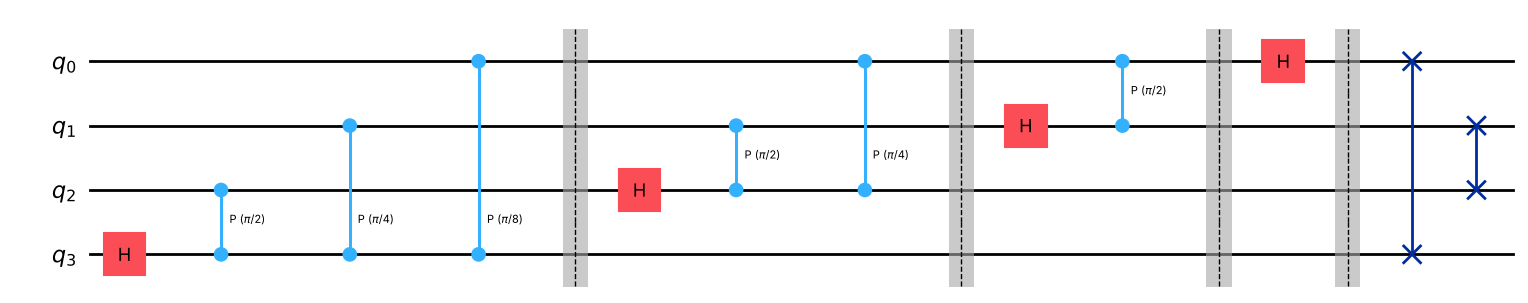

Gate counts: {'cp': 6, 'h': 4, 'swap': 2}
Circuit depth: 11
Formulas: H = n = 4, CP = n(n-1)/2 = 6, SWAP = floor(n/2) = 2
Matches formula matrix: True
Total gates ~ n^2 = 12   vs FFT ops ~ n*2^n = 64


In [8]:
# Program 7: qft(n) for n = 4 - gate counts and depth
n = 4
q4 = qft(n)
show(q4.draw("mpl"))
ops = q4.count_ops()
print("Gate counts:", {k: v for k, v in ops.items() if k != "barrier"})
print("Circuit depth:", q4.remove_final_measurements(inplace=False).depth(lambda g: g.operation.name != "barrier"))
print(f"Formulas: H = n = {n}, CP = n(n-1)/2 = {n*(n-1)//2}, SWAP = floor(n/2) = {n//2}")
print("Matches formula matrix:", np.allclose(Operator(q4).data, qft_matrix(4)))
print(f"Total gates ~ n^2 = {sum(v for k, v in ops.items() if k != 'barrier')}   vs FFT ops ~ n*2^n = {n * 2**n}")

**Inference:** For n = 4 the circuit has 4 H, 6 controlled-phase and 2 SWAP gates, exactly n, n(n−1)/2 and ⌊n/2⌋ from the theory (12 gates in total ≈ n²), and its matrix matches the 16×16 formula.

### Program 8
Prepare the Fourier state of the number 5 on three qubits without using the QFT: apply H to every qubit and then the phase gate $P\left( 2\pi \cdot 5 \cdot 2^{k}/8 \right)$ to qubit $k$. Apply the inverse QFT, measure, and show that the result is 101.

Fourier state equals QFT|101>: True


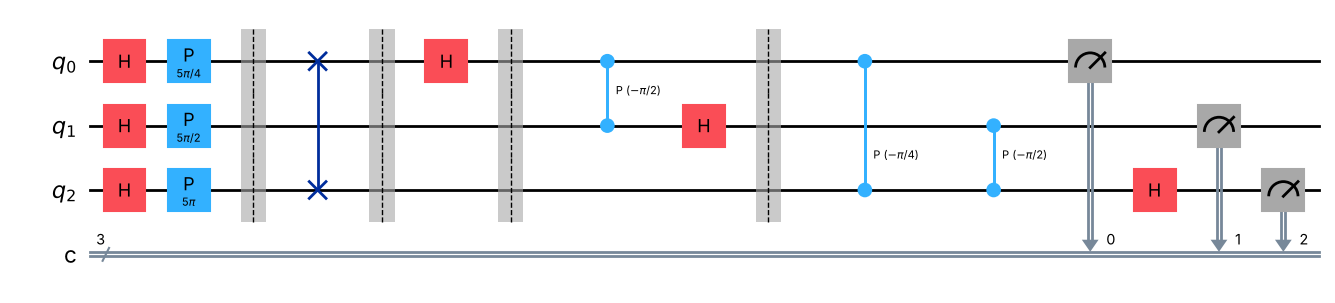

Counts: {'101': 1024}


In [9]:
# Program 8: Fourier state of 5 built directly, then inverse QFT
n, j = 3, 5
qc = QuantumCircuit(n, n)
qc.h(range(n))
for k in range(n):
    qc.p(2 * np.pi * j * 2 ** k / 2 ** n, k)
print("Fourier state equals QFT|101>:",
      np.allclose(Statevector(qc.remove_final_measurements(inplace=False)).data,
                  Statevector.from_label("101").evolve(q3).data))
qc.barrier()
qc.compose(iqft(n), inplace=True)
qc.measure(range(n), range(n))
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)

**Inference:** H on each qubit followed by phases 2π·5·2ᵏ/8 creates exactly QFT|101> (verified), and the inverse QFT converts these phases back into the number: every shot gives 101 = 5. This phase-to-number step is the read-out used in quantum phase estimation.

### Program 9
Prepare the three-qubit state with period 2 (an equal superposition of 0, 2, 4 and 6), apply the QFT and measure. Show that only the outcomes 0 and 4 appear. Repeat for a state with period 4 and explain the pattern.

period r = 2: input superposition of [0, 2, 4, 6]  ->  outcomes [0, 4]  (multiples of N/r = 4)  counts {'000': 524, '100': 500}


period r = 4: input superposition of [0, 4]  ->  outcomes [0, 2, 4, 6]  (multiples of N/r = 2)  counts {'010': 263, '000': 250, '110': 261, '100': 250}


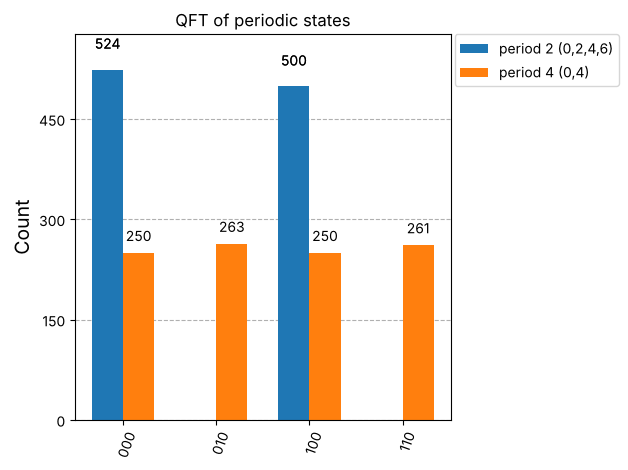

In [10]:
# Program 9: periodic states -> QFT concentrates on multiples of N/r
def periodic(r):
    vals = list(range(0, 8, r))
    v = np.zeros(8); v[vals] = 1 / np.sqrt(len(vals))
    return vals, v

res = []
for r in [2, 4]:
    vals, v = periodic(r)
    qc = QuantumCircuit(3, 3)
    qc.initialize(v, range(3))
    qc.barrier()
    qc.compose(q3, inplace=True)
    qc.measure(range(3), range(3))
    c = run(qc)
    outs = sorted(int(k, 2) for k in c)
    print(f"period r = {r}: input superposition of {vals}  ->  outcomes {outs}  (multiples of N/r = {8//r})  counts {c}")
    res.append(c)
show(plot_histogram(res, legend=["period 2 (0,2,4,6)", "period 4 (0,4)"], title="QFT of periodic states"))

**Inference:** The period-2 state (0,2,4,6) gives only 0 and 4, and the period-4 state (0,4) gives 0, 2, 4 and 6, each about equally often. The QFT output is concentrated on the multiples of N/r (8/2 = 4 and 8/4 = 2), so r = N/spacing can be read from the measured values — the key idea of Shor's period finding.

## Viva Q&A

**1. What does the Quantum Fourier Transform do to a basis state?**  
It maps a basis state |j> to an equal-magnitude superposition of all basis states with phases proportional to j: QFT|j> = (1/√N) Σₖ e^(2πijk/N)|k>.

**2. How is the QFT related to the classical discrete Fourier transform?**  
It is the discrete Fourier transform applied to the vector of amplitudes: the QFT matrix entries are ω^(jk)/√N with ω = e^(2πi/N), i.e. the (unitary-normalised) DFT matrix acting on the quantum state.

**3. Why is the one-qubit QFT the same as the Hadamard gate?**  
For N = 2, ω = e^(iπ) = −1, so the matrix is (1/√2)[[1,1],[1,−1]], which is exactly the Hadamard matrix.

**4. Which gates are used to build an n-qubit QFT, and how many of each?**  
Hadamard gates (n), controlled-phase gates with angles π/2, π/4, … (n(n−1)/2) and SWAP gates (⌊n/2⌋) to reverse the qubit order — O(n²) gates in total.

**5. What does the controlled-phase gate do, and which angles appear in the QFT?**  
The controlled-phase gate CP(θ) multiplies the state by e^(iθ) only when both qubits are 1 (diag(1,1,1,e^(iθ))). In the QFT the angles are π/2^m: π/2, π/4, π/8, … depending on the distance between the qubits.

**6. Why are SWAP gates placed at the end of the QFT circuit?**  
The Hadamard/controlled-phase stages produce the output with the qubits in reversed bit order (the most significant output appears on the least significant qubit). The SWAPs restore the standard order so that the matrix matches the formula; they can be omitted if the reversal is handled classically.

**7. Why can the QFT not be used as a faster FFT to read out all the Fourier coefficients?**  
The Fourier coefficients are stored as amplitudes, and a measurement returns only one basis state with probability |amplitude|². Reading all N coefficients would need exponentially many repetitions, so the QFT is only useful as a subroutine whose output is designed to be measured (period/phase finding).

**8. What is the inverse QFT, and where is it used?**  
The inverse QFT is QFT† (same gates in reverse order with negated angles), mapping (1/√N)Σ e^(2πijk/N)|k> back to |j>. It is used in quantum phase estimation and Shor's algorithm to convert phases into a measurable number.

**9. What does the QFT output look like for an input state with period r?**  
For an input with period r (that divides N), the QFT output is non-zero only on multiples of N/r, i.e. on k = s·N/r, s = 0,…,r−1, each with probability 1/r.

**10. How does the number of gates in the QFT compare with the number of operations in the FFT?**  
The QFT uses about n²/2 gates (O(n²) = O(log² N)), whereas the FFT needs about N log N = n·2ⁿ operations — an exponential difference, but with the read-out limitation described above.

## Result

The Quantum Fourier Transform and its inverse were constructed in Qiskit for 1, 2, 3 and 4 qubits from Hadamard, controlled-phase and SWAP gates. The 1-qubit QFT was shown to be the Hadamard gate, and the 2- and 3-qubit circuits matched the formula matrix e^(2πijk/N)/√N and Qiskit's QFTGate exactly. QFT followed by inverse QFT returned all basis states, the gate counts matched n, n(n−1)/2 and ⌊n/2⌋, the Fourier state of 5 was decoded to 101, and periodic states produced peaks at multiples of N/r. Hence the experiment was successfully completed.